
# **Medical Image Diagnosis Assistant**
# Multi-Label Chest X-ray Disease Classification with Explainability

# Dataset  : NIH ChestX-ray14 (224×224 resized)
# Model    : DenseNet121
# Framework: PyTorch + MONAI


# Cell 1: Environment Setup
#
# This cell prepares the environment for training by installing the
# required libraries, checking GPU availability, enabling mixed precision
# (when supported) for faster training, setting random seeds for
# reproducible results, and displaying the Python and library versions.

In [2]:

!pip install -q torch torchvision "monai>=1.5.0" grad-cam==1.5.4 torchmetrics==1.4.0 pandas scikit-learn matplotlib opencv-python-headless tensorboard

import os
import random
from dataclasses import dataclass, field

import torch
import numpy as np
import monai
from torch.amp import GradScaler

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. In Colab, go to: "
        "Runtime > Change runtime type > Hardware accelerator > GPU (T4 or better), "
        "then re-run this cell."
    )

DEVICE = torch.device("cuda")
GPU_NAME = torch.cuda.get_device_name(0)
GPU_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)


SCALER = GradScaler(device="cuda")

RANDOM_SEED = 42


def set_global_seed(seed: int) -> None:
    """Fix random seeds across every library for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(RANDOM_SEED)


@dataclass
class Config:
    dataset_root: str = "/content/drive/MyDrive/chestxray14"
    images_dir: str = field(init=False)
    data_entry_csv: str = field(init=False)
    bbox_csv: str = field(init=False)
    train_val_list_txt: str = field(init=False)
    test_list_txt: str = field(init=False)

    output_root: str = "/content/drive/MyDrive/chestxray14_project/outputs"
    checkpoints_dir: str = field(init=False)
    gradcam_dir: str = field(init=False)
    metrics_dir: str = field(init=False)
    logs_dir: str = field(init=False)
    splits_dir: str = field(init=False)

    image_size: int = 224
    val_fraction: float = 0.2
    random_seed: int = 42

    batch_size: int = 64
    num_workers: int = 4
    frozen_epochs: int = 3
    finetune_epochs: int = 8
    lr_frozen: float = 1e-3
    lr_finetune: float = 1e-5
    weight_decay: float = 1e-5
    early_stopping_patience: int = 3
    lr_scheduler_patience: int = 2
    lr_scheduler_factor: float = 0.5

    threshold_default: float = 0.5

    def __post_init__(self):
        self.images_dir = self._resolve_images_dir(self.dataset_root)
        self.data_entry_csv = os.path.join(self.dataset_root, "Data_Entry_2017.csv")
        self.bbox_csv = os.path.join(self.dataset_root, "BBox_List_2017_Official_NIH.csv")
        self.train_val_list_txt = os.path.join(self.dataset_root, "train_val_list_NIH.txt")
        self.test_list_txt = os.path.join(self.dataset_root, "test_list_NIH.txt")

        self.checkpoints_dir = os.path.join(self.output_root, "checkpoints")
        self.gradcam_dir = os.path.join(self.output_root, "gradcam")
        self.metrics_dir = os.path.join(self.output_root, "metrics")
        self.logs_dir = os.path.join(self.output_root, "logs")
        self.splits_dir = os.path.join(self.output_root, "splits")

        for d in (self.output_root, self.checkpoints_dir, self.gradcam_dir,
                  self.metrics_dir, self.logs_dir, self.splits_dir):
            os.makedirs(d, exist_ok=True)

    @staticmethod
    def _resolve_images_dir(dataset_root: str) -> str:
        """Find the folder actually containing the .png files.

        Some Kaggle mirrors nest images as images-224/images-224/*.png
        instead of the expected images-224/*.png.
        """
        outer = os.path.join(dataset_root, "images-224")
        nested = os.path.join(outer, "images-224")

        def has_images(path):
            return os.path.isdir(path) and any(
                f.lower().endswith((".png", ".jpg", ".jpeg")) for f in os.listdir(path)
            )

        if has_images(outer):
            return outer
        if has_images(nested):
            return nested
        return outer


def verify_dataset_paths(cfg: "Config") -> None:
    """Raise a clear error if any required dataset file is missing."""
    required = {
        "images-224/ directory": cfg.images_dir,
        "Data_Entry_2017.csv": cfg.data_entry_csv,
        "BBox_List_2017_Official_NIH.csv": cfg.bbox_csv,
        "train_val_list_NIH.txt": cfg.train_val_list_txt,
        "test_list_NIH.txt": cfg.test_list_txt,
    }
    missing = [name for name, path in required.items() if not os.path.exists(path)]
    if missing:
        raise FileNotFoundError(
            "The following required dataset files/folders were not found:\n"
            + "\n".join(f"  - {m}" for m in missing)
            + f"\n\nCheck that CONFIG.dataset_root ('{cfg.dataset_root}') "
              "points to the correct folder (run Cell 2 -- Dataset Acquisition "
              "-- if you have not already)."
        )
    num_images = len([f for f in os.listdir(cfg.images_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    print(f"Dataset paths verified. Images found in images-224/: {num_images}")


CONFIG = Config()

if os.path.exists(CONFIG.data_entry_csv):
    verify_dataset_paths(CONFIG)
else:
    print("Dataset not found yet at CONFIG.dataset_root -- run Cell 2 (Dataset Acquisition) next.")

print(f"GPU: {GPU_NAME} ({GPU_VRAM_GB:.1f} GB) | PyTorch {torch.__version__} | "
      f"MONAI {monai.__version__} | seed={RANDOM_SEED}")
print(f"Dataset root: {CONFIG.dataset_root}")
print(f"Images dir  : {CONFIG.images_dir}")


Dataset not found yet at CONFIG.dataset_root -- run Cell 2 (Dataset Acquisition) next.
GPU: Tesla T4 (14.6 GB) | PyTorch 2.11.0+cu128 | MONAI 1.6.0 | seed=42
Dataset root: /content/drive/MyDrive/chestxray14
Images dir  : /content/drive/MyDrive/chestxray14/images-224


# Cell 2: Dataset Download and Setup
#
# Downloads the NIH ChestX-ray14 (224×224 resized) dataset using kagglehub.
# Saves a copy in Google Drive and stages the images to Colab's local storage
# for faster training. Kaggle credentials are loaded securely from Colab Secrets.

In [3]:
!pip install -q kagglehub

import os
import shutil
import time

import kagglehub

try:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
except Exception as secrets_error:
    kaggle_json_path = os.path.expanduser("~/.kaggle/kaggle.json")
    if not os.path.exists(kaggle_json_path):
        raise RuntimeError(
            "Could not find Kaggle credentials. Either:\n"
            "  (a) Add KAGGLE_USERNAME and KAGGLE_KEY as Colab Secrets "
            "(key icon in the left sidebar), and enable notebook access, or\n"
            "  (b) Upload your kaggle.json to ~/.kaggle/kaggle.json manually.\n"
            f"Original error: {secrets_error}"
        )

KAGGLE_DATASET_HANDLE = "khanfashee/nih-chest-x-ray-14-224x224-resized"

print(f"Downloading {KAGGLE_DATASET_HANDLE} from Kaggle...")
kaggle_cache_path = kagglehub.dataset_download(KAGGLE_DATASET_HANDLE)

DRIVE_DATASET_ROOT = "/content/drive/MyDrive/chestxray14"
drive_marker_file = os.path.join(DRIVE_DATASET_ROOT, "Data_Entry_2017.csv")

if not os.path.exists(drive_marker_file):
    print(f"Copying to Drive ({DRIVE_DATASET_ROOT}) for persistence...")
    os.makedirs(DRIVE_DATASET_ROOT, exist_ok=True)
    shutil.copytree(kaggle_cache_path, DRIVE_DATASET_ROOT, dirs_exist_ok=True)

CONFIG.dataset_root = DRIVE_DATASET_ROOT
CONFIG.__post_init__()
verify_dataset_paths(CONFIG)

# Reading files
LOCAL_IMAGES_DIR = "/content/images-224-local"


def stage_images_locally(source_images_dir: str, local_images_dir: str) -> str:
    """Copy the resolved images directory to local disk if not already staged."""
    marker_file = os.path.join(local_images_dir, ".staging_complete")
    if os.path.exists(marker_file):
        return local_images_dir

    print(f"Staging images to local disk ({local_images_dir})...")
    start_time = time.time()
    os.makedirs(local_images_dir, exist_ok=True)
    shutil.copytree(source_images_dir, local_images_dir, dirs_exist_ok=True)
    with open(marker_file, "w") as f:
        f.write("complete")
    print(f"Done in {time.time() - start_time:.0f}s.")
    return local_images_dir


CONFIG.images_dir = stage_images_locally(CONFIG.images_dir, LOCAL_IMAGES_DIR)
print(f"Images dir: {CONFIG.images_dir}")


Using Colab cache for faster access to the 'nih-chest-x-ray-14-224x224-resized' dataset.
Copying to Drive (/content/drive/MyDrive/chestxray14) for persistence...
Dataset paths verified. Images found in images-224/: 112120
Staging images to local disk (/content/images-224-local)...
Done in 67s.
Images dir: /content/images-224-local


# Cell 3: Data Exploration
#
# Loads the dataset metadata from Data_Entry_2017.csv, converts the
# disease labels into a multi-label (multi-hot) format, and displays
# class distribution, dataset statistics, and a few sample images.
# All paths are loaded from the CONFIG object defined earlier.

Loaded 112120 rows.
14 disease classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

112120 images, 30805 patients (3.64 avg per patient)
No Finding: 60412 (53.9%)  >=1 finding: 51708 (46.1%)  avg findings/diseased image: 0.72

Class distribution:
             Class  Positive Count  Positive %
      Infiltration           19870       17.72
          Effusion           13307       11.87
       Atelectasis           11535       10.29
            Nodule            6323        5.64
              Mass            5746        5.12
      Pneumothorax            5298        4.73
     Consolidation            4667        4.16
Pleural_Thickening            3385        3.02
      Cardiomegaly            2772        2.47
         Emphysema            2516        2.24
             Edema            2303        2.05
          Fibrosis            1686        

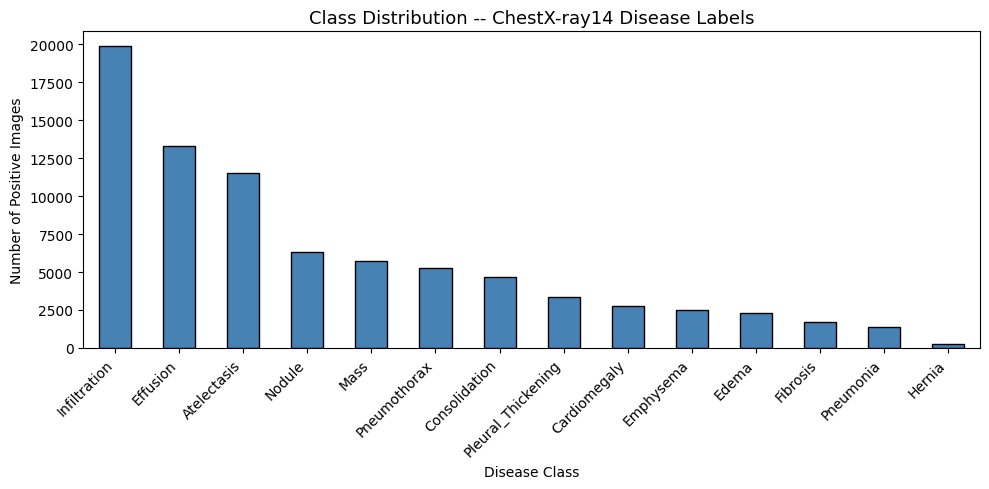

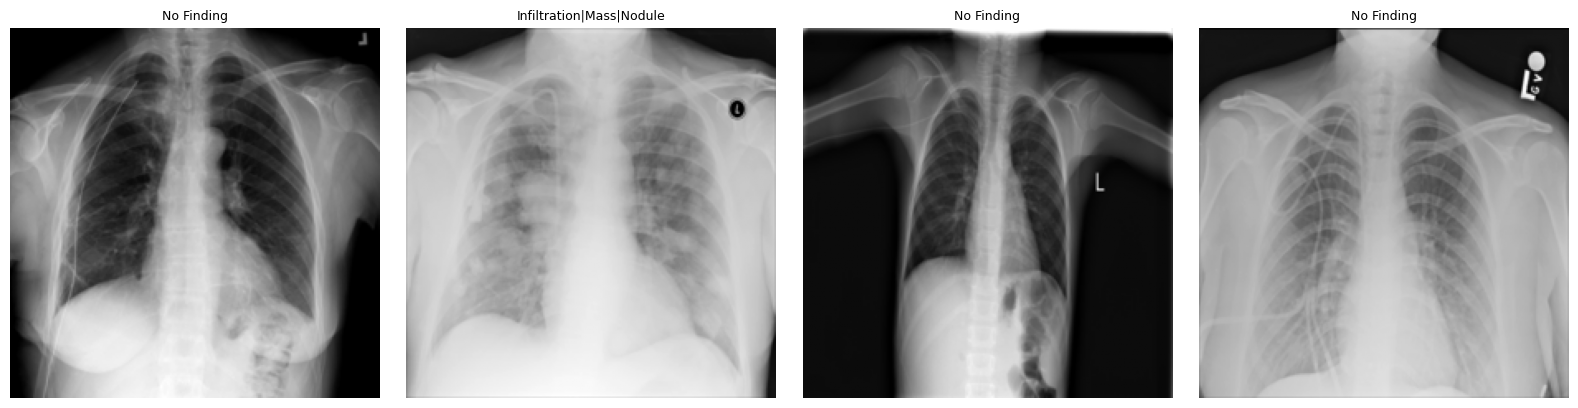

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IMAGES_DIR = CONFIG.images_dir
DATA_ENTRY_CSV = CONFIG.data_entry_csv

if not os.path.exists(DATA_ENTRY_CSV):
    raise FileNotFoundError(
        f"Could not find Data_Entry_2017.csv at {DATA_ENTRY_CSV}. "
        "Make sure Cell 2 (Dataset Acquisition) ran successfully first."
    )

data_entry_df = pd.read_csv(DATA_ENTRY_CSV)
print(f"Loaded {len(data_entry_df)} rows.")
data_entry_df.head()


def parse_all_labels(df: pd.DataFrame, label_column: str = "Finding Labels") -> list:
    """Return the sorted list of unique disease labels present in the dataset."""
    unique_labels = set()
    for label_string in df[label_column]:
        unique_labels.update(label_string.split("|"))
    return sorted(unique_labels)


ALL_LABELS = parse_all_labels(data_entry_df)
DISEASE_LABELS = [lbl for lbl in ALL_LABELS if lbl != "No Finding"]
NUM_CLASSES = len(DISEASE_LABELS)
print(f"{NUM_CLASSES} disease classes: {DISEASE_LABELS}")

for label in DISEASE_LABELS:
    data_entry_df[label] = data_entry_df["Finding Labels"].apply(
        lambda finding_string, lbl=label: 1 if lbl in finding_string.split("|") else 0
    )

data_entry_df["No Finding Flag"] = data_entry_df["Finding Labels"].apply(
    lambda s: 1 if s == "No Finding" else 0
)

num_images = len(data_entry_df)
num_patients = data_entry_df["Patient ID"].nunique()
avg_images_per_patient = num_images / num_patients
num_healthy = int(data_entry_df["No Finding Flag"].sum())
num_with_findings = num_images - num_healthy
avg_labels_per_image = data_entry_df[DISEASE_LABELS].sum(axis=1).mean()

print(f"\n{num_images} images, {num_patients} patients ({avg_images_per_patient:.2f} avg per patient)")
print(f"No Finding: {num_healthy} ({100*num_healthy/num_images:.1f}%)  "
      f">=1 finding: {num_with_findings} ({100*num_with_findings/num_images:.1f}%)  "
      f"avg findings/diseased image: {avg_labels_per_image:.2f}")

class_counts = data_entry_df[DISEASE_LABELS].sum().sort_values(ascending=False)
class_percentages = (class_counts / num_images * 100).round(2)

class_distribution_df = pd.DataFrame({
    "Class": class_counts.index,
    "Positive Count": class_counts.values,
    "Positive %": class_percentages.values,
})
print("\nClass distribution:")
print(class_distribution_df.to_string(index=False))


imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nMost/least frequent class imbalance ratio: {imbalance_ratio:.1f}x")

fig, ax = plt.subplots(figsize=(10, 5))
class_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Class Distribution -- ChestX-ray14 Disease Labels", fontsize=13)
ax.set_ylabel("Number of Positive Images")
ax.set_xlabel("Disease Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


def sanity_check_samples(df: pd.DataFrame, images_dir: str, num_samples: int = 4, seed: int = 42) -> None:
    """Display random sample images with their labels; verify files exist on disk."""
    sample_df = df.sample(n=min(num_samples, len(df)), random_state=seed)
    missing_files = []
    fig, axes = plt.subplots(1, len(sample_df), figsize=(4 * len(sample_df), 4))
    if len(sample_df) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image_path = os.path.join(images_dir, row["Image Index"])
        if not os.path.exists(image_path):
            missing_files.append(image_path)
            ax.set_title(f"MISSING FILE\n{row['Image Index']}", fontsize=9, color="red")
            ax.axis("off")
            continue
        image = plt.imread(image_path)
        ax.imshow(image, cmap="gray")
        ax.set_title(f"{row['Finding Labels']}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    if missing_files:
        raise FileNotFoundError(
            f"{len(missing_files)} sample image(s) referenced in the CSV were "
            f"not found in {images_dir}:\n" + "\n".join(missing_files)
        )


sanity_check_samples(data_entry_df, IMAGES_DIR, num_samples=4, seed=42)


# Cell 4: Label Engineering and Data Split
#
# Creates the multi-hot label matrix and applies the official NIH
# train/test split. The training set is further divided into train
# and validation sets using Patient ID (80:20) to prevent data leakage.
# Finally, train.csv, val.csv, and test.csv are saved for model training.

Loaded 112120 images, 14 disease classes.
train_val_list_NIH.txt : 86524 images
test_list_NIH.txt      : 25596 images
Matched in CSV -- train_val: 86524/86524, test: 25596/25596
Patient-disjointness verified: no leakage across train/val/test.

Split summary:
     Split  Images  Patients  Image %
     Train   69086     22406     61.6
Validation   17438      5602     15.6
      Test   25596      2797     22.8

Per-class positive rate (%) by split:
                    Train %  Val %  Test %
Atelectasis            9.49   9.89   12.72
Cardiomegaly           1.97   1.97    4.16
Consolidation          3.21   3.64    7.09
Edema                  1.57   1.67    3.61
Effusion               9.85  10.63   18.16
Emphysema              1.59   1.85    4.27
Fibrosis               1.44   1.48    1.70
Hernia                 0.17   0.14    0.34
Infiltration          15.82  16.34   23.78
Mass                   4.71   4.48    6.69
Nodule                 5.37   5.72    6.31
Pleural_Thickening     2.55   2.74

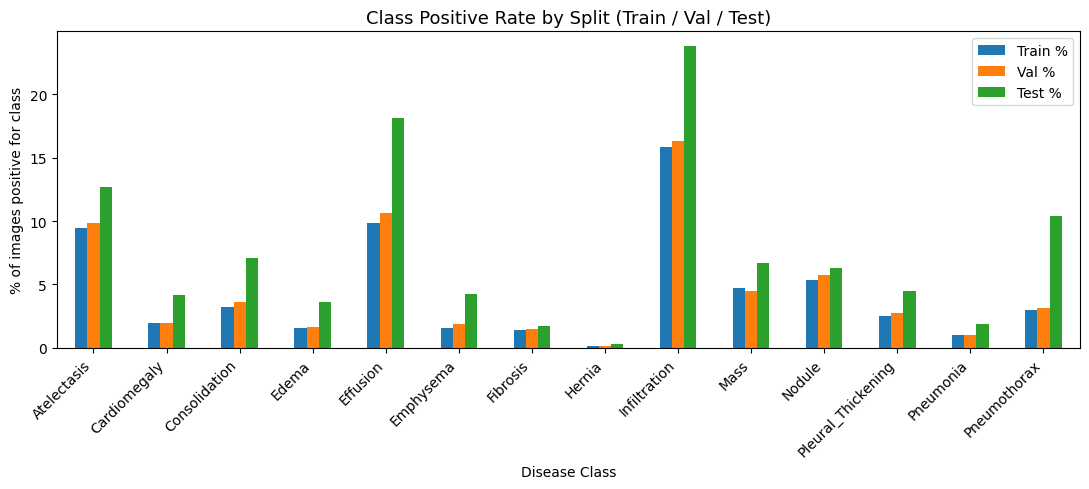


Saved to /content/drive/MyDrive/chestxray14_project/outputs/splits: train (69086), val (17438), test (25596), 14 classes.


In [5]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_entry_df = pd.read_csv(CONFIG.data_entry_csv)


def parse_all_labels(df: pd.DataFrame, label_column: str = "Finding Labels") -> list:
    """Return the sorted list of unique disease labels present in the dataset."""
    unique_labels = set()
    for label_string in df[label_column]:
        unique_labels.update(label_string.split("|"))
    return sorted(unique_labels)


ALL_LABELS = parse_all_labels(data_entry_df)
DISEASE_LABELS = [lbl for lbl in ALL_LABELS if lbl != "No Finding"]
NUM_CLASSES = len(DISEASE_LABELS)

for label in DISEASE_LABELS:
    data_entry_df[label] = data_entry_df["Finding Labels"].apply(
        lambda finding_string, lbl=label: 1 if lbl in finding_string.split("|") else 0
    )

print(f"Loaded {len(data_entry_df)} images, {NUM_CLASSES} disease classes.")


def load_image_list(txt_path: str) -> set:
    """Read a newline-delimited list of image filenames into a set."""
    with open(txt_path, "r") as f:
        return set(line.strip() for line in f if line.strip())


train_val_image_names = load_image_list(CONFIG.train_val_list_txt)
test_image_names = load_image_list(CONFIG.test_list_txt)

print(f"train_val_list_NIH.txt : {len(train_val_image_names)} images")
print(f"test_list_NIH.txt      : {len(test_image_names)} images")

list_overlap = train_val_image_names & test_image_names
if list_overlap:
    raise ValueError(
        f"{len(list_overlap)} image(s) appear in BOTH train_val_list_NIH.txt "
        f"and test_list_NIH.txt. This should never happen -- check the "
        f"source files. Example overlapping filenames: {list(list_overlap)[:5]}"
    )

train_val_df = data_entry_df[data_entry_df["Image Index"].isin(train_val_image_names)].reset_index(drop=True)
test_df = data_entry_df[data_entry_df["Image Index"].isin(test_image_names)].reset_index(drop=True)

matched_train_val = len(train_val_df)
matched_test = len(test_df)
print(f"Matched in CSV -- train_val: {matched_train_val}/{len(train_val_image_names)}, "
      f"test: {matched_test}/{len(test_image_names)}")

if matched_train_val < len(train_val_image_names) or matched_test < len(test_image_names):
    print(
        "WARNING: not every filename in the official split lists was found "
        "in Data_Entry_2017.csv. This can happen if the CSV and split lists "
        "come from slightly different dataset versions -- proceeding with "
        "only the matched images."
    )


def patient_disjoint_split(df: pd.DataFrame, val_fraction: float, seed: int) -> tuple:
    """Split by Patient ID (not row) so no patient appears in both train and val."""
    unique_patient_ids = df["Patient ID"].unique()
    rng = np.random.default_rng(seed)
    shuffled_patient_ids = unique_patient_ids.copy()
    rng.shuffle(shuffled_patient_ids)

    num_val_patients = int(round(len(shuffled_patient_ids) * val_fraction))
    val_patient_ids = set(shuffled_patient_ids[:num_val_patients])
    train_patient_ids = set(shuffled_patient_ids[num_val_patients:])

    train_split_df = df[df["Patient ID"].isin(train_patient_ids)].reset_index(drop=True)
    val_split_df = df[df["Patient ID"].isin(val_patient_ids)].reset_index(drop=True)
    return train_split_df, val_split_df


train_df, val_df = patient_disjoint_split(
    train_val_df, val_fraction=CONFIG.val_fraction, seed=CONFIG.random_seed
)

# Train vs val
train_patient_ids = set(train_df["Patient ID"])
val_patient_ids = set(val_df["Patient ID"])
test_patient_ids = set(test_df["Patient ID"])

assert train_patient_ids.isdisjoint(val_patient_ids), (
    "Patient leakage detected between train and val -- this indicates a bug "
    "in patient_disjoint_split() and must be fixed before proceeding."
)

train_test_overlap = train_patient_ids & test_patient_ids
val_test_overlap = val_patient_ids & test_patient_ids
if train_test_overlap or val_test_overlap:
    print(
        "WARNING: the official train_val_list_NIH.txt / test_list_NIH.txt "
        "files are NOT patient-disjoint for this dataset copy -- "
        f"{len(train_test_overlap)} patient(s) overlap train/test, "
        f"{len(val_test_overlap)} patient(s) overlap val/test. This means "
        "some test-set images may share a patient with training images, "
        "which can inflate test metrics. This is a property of the source "
        "data files, not of this notebook's code -- proceeding anyway, but "
        "keep this in mind when interpreting test-set results."
    )
else:
    print("Patient-disjointness verified: no leakage across train/val/test.")

split_summary_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(train_df), len(val_df), len(test_df)],
    "Patients": [len(train_patient_ids), len(val_patient_ids), len(test_patient_ids)],
})
split_summary_df["Image %"] = (
    split_summary_df["Images"] / split_summary_df["Images"].sum() * 100
).round(1)
print("\nSplit summary:")
print(split_summary_df.to_string(index=False))

class_dist_by_split = pd.DataFrame({
    "Train %": (train_df[DISEASE_LABELS].sum() / max(len(train_df), 1) * 100),
    "Val %": (val_df[DISEASE_LABELS].sum() / max(len(val_df), 1) * 100),
    "Test %": (test_df[DISEASE_LABELS].sum() / max(len(test_df), 1) * 100),
}).round(2)
print("\nPer-class positive rate (%) by split:")
print(class_dist_by_split.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
class_dist_by_split.plot(kind="bar", ax=ax)
ax.set_title("Class Positive Rate by Split (Train / Val / Test)", fontsize=13)
ax.set_ylabel("% of images positive for class")
ax.set_xlabel("Disease Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

manifest_columns = ["Image Index", "Patient ID", "Finding Labels"] + DISEASE_LABELS

train_csv_path = os.path.join(CONFIG.splits_dir, "train.csv")
val_csv_path = os.path.join(CONFIG.splits_dir, "val.csv")
test_csv_path = os.path.join(CONFIG.splits_dir, "test.csv")

train_df[manifest_columns].to_csv(train_csv_path, index=False)
val_df[manifest_columns].to_csv(val_csv_path, index=False)
test_df[manifest_columns].to_csv(test_csv_path, index=False)

labels_json_path = os.path.join(CONFIG.splits_dir, "disease_labels.json")
with open(labels_json_path, "w") as f:
    json.dump(DISEASE_LABELS, f, indent=2)

print(f"\nSaved to {CONFIG.splits_dir}: train ({len(train_df)}), "
      f"val ({len(val_df)}), test ({len(test_df)}), {NUM_CLASSES} classes.")


# Cell 5: Dataset and MONAI Transforms
#
# Creates the PyTorch Dataset using the train, validation, and test
# split files. MONAI transforms are applied with data augmentation
# for training and standard preprocessing for validation/testing.
# DataLoaders are created, and a sample batch is displayed to verify
# the preprocessing pipeline before training the model.

14 disease classes loaded.
Train/Val/Test: 69086/17438/25596 images

Batches per epoch -- train: 1079, val: 273, test: 400


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Batch shapes: images (64, 3, 224, 224), labels (64, 14)


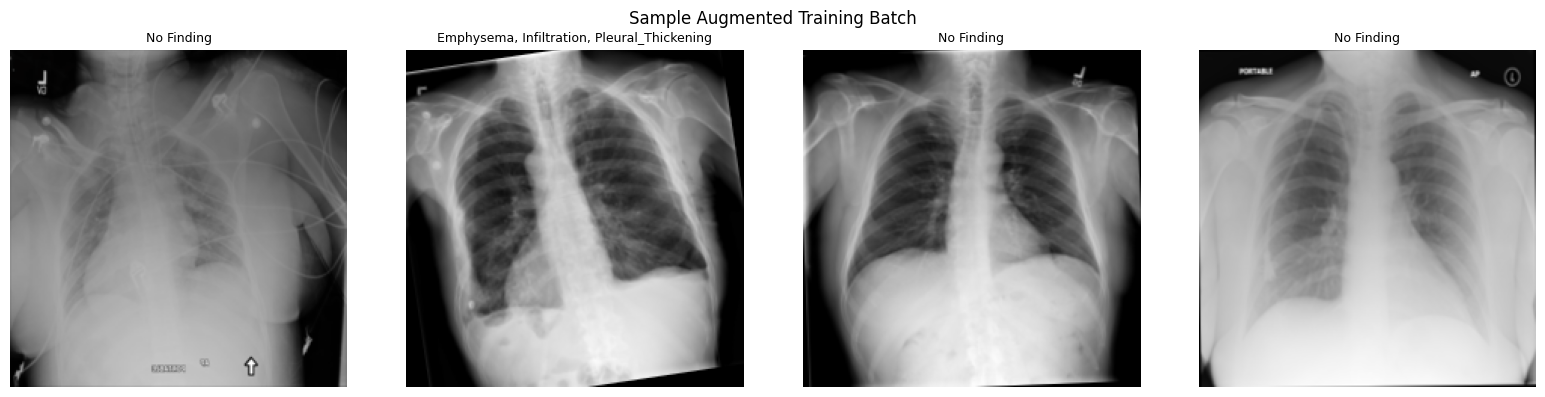

In [6]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    Compose, EnsureChannelFirst, ScaleIntensity, RepeatChannel, Resize,
    RandFlip, RandRotate, RandAdjustContrast, RandGaussianNoise,
    NormalizeIntensity, ToTensor,
)

labels_json_path = os.path.join(CONFIG.splits_dir, "disease_labels.json")
if not os.path.exists(labels_json_path):
    raise FileNotFoundError(
        f"Could not find {labels_json_path}. Run Cell 4 (Label Engineering & "
        "Split) first -- it produces this file along with train/val/test.csv."
    )
with open(labels_json_path, "r") as f:
    DISEASE_LABELS = json.load(f)
NUM_CLASSES = len(DISEASE_LABELS)
print(f"{NUM_CLASSES} disease classes loaded.")


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

_shared_prefix = [
    EnsureChannelFirst(channel_dim="no_channel"),
    ScaleIntensity(minv=0.0, maxv=1.0),
    RepeatChannel(repeats=3),
    Resize(spatial_size=(CONFIG.image_size, CONFIG.image_size)),
]
_shared_suffix = [
    NormalizeIntensity(subtrahend=IMAGENET_MEAN, divisor=IMAGENET_STD, channel_wise=True),
    ToTensor(),
]


train_transforms = Compose(_shared_prefix + [
    RandFlip(prob=0.5, spatial_axis=1),
    RandRotate(range_x=0.175, prob=0.5, padding_mode="zeros"),
    RandAdjustContrast(prob=0.5, gamma=(0.8, 1.2)),
    RandGaussianNoise(prob=0.2, mean=0.0, std=0.01),
] + _shared_suffix)

eval_transforms = Compose(_shared_prefix + _shared_suffix)


class ChestXrayDataset(Dataset):
    """Multi-label chest X-ray dataset reading from a split manifest CSV."""

    def __init__(self, manifest_csv_path: str, images_dir: str,
                 disease_labels: list, transform: Compose):
        self.manifest_df = pd.read_csv(manifest_csv_path)
        self.images_dir = images_dir
        self.disease_labels = disease_labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.manifest_df)

    def __getitem__(self, index: int):
        row = self.manifest_df.iloc[index]
        image_path = os.path.join(self.images_dir, row["Image Index"])

        if not os.path.exists(image_path):
            raise FileNotFoundError(
                f"Image file not found: {image_path}. This manifest row "
                f"expects it to exist -- check CONFIG.images_dir is correct."
            )


        pil_image = Image.open(image_path).convert("L")
        image_array = np.array(pil_image)

        transformed_image = self.transform(image_array)

        label_values = row[self.disease_labels].values.astype(np.float32)
        label_tensor = torch.from_numpy(label_values)

        return transformed_image, label_tensor


train_dataset = ChestXrayDataset(
    manifest_csv_path=os.path.join(CONFIG.splits_dir, "train.csv"),
    images_dir=CONFIG.images_dir,
    disease_labels=DISEASE_LABELS,
    transform=train_transforms,
)
val_dataset = ChestXrayDataset(
    manifest_csv_path=os.path.join(CONFIG.splits_dir, "val.csv"),
    images_dir=CONFIG.images_dir,
    disease_labels=DISEASE_LABELS,
    transform=eval_transforms,
)
test_dataset = ChestXrayDataset(
    manifest_csv_path=os.path.join(CONFIG.splits_dir, "test.csv"),
    images_dir=CONFIG.images_dir,
    disease_labels=DISEASE_LABELS,
    transform=eval_transforms,
)

print(f"Train/Val/Test: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)} images")

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=True,
    num_workers=CONFIG.num_workers,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=False,
    num_workers=CONFIG.num_workers,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=False,
    num_workers=CONFIG.num_workers,
    pin_memory=True,
)

print(f"\nBatches per epoch -- train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


def denormalize_for_display(image_tensor: torch.Tensor) -> np.ndarray:
    """Reverse ImageNet normalization for display -- returns (H, W, 3) in [0, 1]."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    denormalized = image_tensor * std + mean
    denormalized = denormalized.clamp(0, 1)
    return denormalized.permute(1, 2, 0).numpy()


sample_images, sample_labels = next(iter(train_loader))
print(f"\nBatch shapes: images {tuple(sample_images.shape)}, labels {tuple(sample_labels.shape)}")

num_to_show = min(4, sample_images.shape[0])
fig, axes = plt.subplots(1, num_to_show, figsize=(4 * num_to_show, 4))
if num_to_show == 1:
    axes = [axes]

for i in range(num_to_show):
    display_image = denormalize_for_display(sample_images[i])
    positive_classes = [
        DISEASE_LABELS[j] for j in range(NUM_CLASSES) if sample_labels[i, j] == 1
    ]
    title = ", ".join(positive_classes) if positive_classes else "No Finding"
    axes[i].imshow(display_image)
    axes[i].set_title(title, fontsize=9)
    axes[i].axis("off")

plt.suptitle("Sample Augmented Training Batch", fontsize=12)
plt.tight_layout()
plt.show()


# Cell 6: Model Definition
#
# Defines the DenseNet121 model with ImageNet pretrained weights and
# replaces the final layer for multi-label disease classification.
# Includes utilities to freeze and unfreeze the backbone for
# two-stage training. The model outputs raw logits, which are
# used directly with BCEWithLogitsLoss during training.

In [7]:
import json
import torch
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights

labels_json_path = os.path.join(CONFIG.splits_dir, "disease_labels.json")
if not os.path.exists(labels_json_path):
    raise FileNotFoundError(
        f"Could not find {labels_json_path}. Run Cell 4 (Label Engineering & "
        "Split) first."
    )
with open(labels_json_path, "r") as f:
    DISEASE_LABELS = json.load(f)
NUM_CLASSES = len(DISEASE_LABELS)


def build_model(num_classes: int) -> nn.Module:
    """Build a DenseNet121 with an ImageNet-pretrained backbone and a fresh
    classifier head sized for our multi-label task."""
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model


def freeze_backbone(model: nn.Module) -> None:
    """Freeze every parameter except the classifier head (phase 1 training)."""
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("classifier")


def unfreeze_all(model: nn.Module) -> None:
    """Unfreeze every parameter in the model (phase 2 fine-tuning)."""
    for param in model.parameters():
        param.requires_grad = True


def count_parameters(model: nn.Module) -> tuple:
    """Return (total_params, trainable_params) for a model."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model = build_model(NUM_CLASSES)
freeze_backbone(model)
model = model.to(DEVICE)

total_params, trainable_params = count_parameters(model)
print(f"DenseNet121: {total_params:,} params ({trainable_params:,} trainable, "
      f"classifier head only) on {next(model.parameters()).device}")


model.eval()
with torch.no_grad():
    dummy_batch = torch.randn(2, 3, CONFIG.image_size, CONFIG.image_size, device=DEVICE)
    dummy_output = model(dummy_batch)
model.train()

expected_shape = (2, NUM_CLASSES)
actual_shape = tuple(dummy_output.shape)
assert actual_shape == expected_shape, (
    f"Model output shape mismatch: expected {expected_shape}, got {actual_shape}"
)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 90.4MB/s]


DenseNet121: 6,968,206 params (14,350 trainable, classifier head only) on cuda:0


# Cell 7: Loss Function, Optimizer, and Scheduler
#
# Calculates class weights from the training data to handle class
# imbalance using BCEWithLogitsLoss with pos_weight. Sets up the
# optimizer for transfer learning and uses ReduceLROnPlateau to
# adjust the learning rate based on the validation macro-AUC score.

In [8]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

train_manifest_path = os.path.join(CONFIG.splits_dir, "train.csv")
if not os.path.exists(train_manifest_path):
    raise FileNotFoundError(
        f"Could not find {train_manifest_path}. Run Cell 4 (Label Engineering "
        "& Split) first."
    )
train_manifest_df = pd.read_csv(train_manifest_path)


def compute_pos_weight(df: pd.DataFrame, disease_labels: list, max_weight: float = 10.0) -> torch.Tensor:
    """Compute per-class positive weights for BCEWithLogitsLoss.

    pos_weight = num_negative / num_positive, upweighting rare classes so
    they aren't drowned out by negatives. Capped at max_weight since
    extremely rare classes can otherwise produce weights in the hundreds,
    destabilizing training.
    """
    weights = []
    for label in disease_labels:
        num_positive = df[label].sum()
        num_negative = len(df) - num_positive
        if num_positive == 0:
            print(f"WARNING: class '{label}' has 0 positive examples in the "
                  f"train split -- falling back to pos_weight=1.0 for it.")
            weights.append(1.0)
            continue
        raw_weight = num_negative / num_positive
        weights.append(min(raw_weight, max_weight))
    return torch.tensor(weights, dtype=torch.float32)


POS_WEIGHT_MAX = 10.0
pos_weight = compute_pos_weight(train_manifest_df, DISEASE_LABELS, max_weight=POS_WEIGHT_MAX)

print(f"Per-class pos_weight (capped at {POS_WEIGHT_MAX}):")
for label, weight in zip(DISEASE_LABELS, pos_weight.tolist()):
    print(f"  {label:15s}: {weight:.2f}")

pos_weight = pos_weight.to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def build_optimizer(model: nn.Module, learning_rate: float, weight_decay: float) -> AdamW:
    """Build an AdamW optimizer over only the currently-trainable parameters.

    Filtering to requires_grad=True matters for the two-phase strategy:
    only the classifier head is trainable in phase 1. Cell 8 calls this
    again after unfreeze_all() for a fresh phase-2 optimizer.
    """
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    return AdamW(trainable_params, lr=learning_rate, weight_decay=weight_decay)


optimizer = build_optimizer(model, learning_rate=CONFIG.lr_frozen, weight_decay=CONFIG.weight_decay)


scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=CONFIG.lr_scheduler_factor,
    patience=CONFIG.lr_scheduler_patience,
)


Per-class pos_weight (capped at 10.0):
  Atelectasis    : 9.54
  Cardiomegaly   : 10.00
  Consolidation  : 10.00
  Edema          : 10.00
  Effusion       : 9.15
  Emphysema      : 10.00
  Fibrosis       : 10.00
  Hernia         : 10.00
  Infiltration   : 5.32
  Mass           : 10.00
  Nodule         : 10.00
  Pleural_Thickening: 10.00
  Pneumonia      : 10.00
  Pneumothorax   : 10.00


# Cell 8a: Training Utilities
#
# Defines the training and validation functions, along with early
# stopping, model checkpointing, and per-class AUC evaluation.
# These utilities are used to train the model in two phases and
# save the best-performing model based on validation performance.

In [9]:
import os
import time
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from torch.utils.tensorboard import SummaryWriter


class EarlyStopping:
    """Tracks the best value of a monitored metric and signals when to stop."""

    def __init__(self, patience: int, mode: str = "max", min_delta: float = 0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, current_score: float) -> bool:
        """Update with a new epoch's metric. Returns True if this is a new best."""
        if self.best_score is None:
            self.best_score = current_score
            return True

        if self.mode == "max":
            improved = current_score > self.best_score + self.min_delta
        else:
            improved = current_score < self.best_score - self.min_delta

        if improved:
            self.best_score = current_score
            self.counter = 0
            return True

        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


def save_checkpoint(model: torch.nn.Module, optimizer: torch.optim.Optimizer,
                     epoch: int, metric_value: float, filepath: str) -> None:
    """Save model + optimizer state, epoch, and metric to a single .pth file."""
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "metric_value": metric_value,
    }, filepath)


def load_checkpoint(model: torch.nn.Module, filepath: str, device: torch.device) -> dict:
    """Load checkpoint weights into `model` in-place; return the full checkpoint dict."""
    checkpoint = torch.load(filepath, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return checkpoint


def compute_multilabel_auc(probabilities: np.ndarray, labels: np.ndarray,
                            disease_labels: list) -> tuple:
    """Compute per-class and macro-averaged AUC-ROC.

    AUC is undefined for a class with only one label value present in the
    split (all-positive or all-negative) -- such classes are excluded from
    the macro average (NaN in the per-class result) rather than raising.
    """
    per_class_auc = {}
    valid_aucs = []
    for class_index, label_name in enumerate(disease_labels):
        y_true = labels[:, class_index]
        y_score = probabilities[:, class_index]
        if len(np.unique(y_true)) < 2:
            per_class_auc[label_name] = float("nan")
            continue
        auc = roc_auc_score(y_true, y_score)
        per_class_auc[label_name] = auc
        valid_aucs.append(auc)

    macro_auc = float(np.mean(valid_aucs)) if valid_aucs else float("nan")
    return macro_auc, per_class_auc


def train_one_epoch(model: torch.nn.Module, loader, criterion, optimizer,
                     scaler, device: torch.device) -> float:
    """Run one training epoch with mixed precision. Returns average loss."""
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


def validate_one_epoch(model: torch.nn.Module, loader, criterion,
                        device: torch.device, disease_labels: list) -> tuple:
    """Run one validation epoch. Returns (loss, macro_auc, per_class_auc)."""
    model.eval()
    running_loss = 0.0
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            all_probabilities.append(torch.sigmoid(outputs.float()).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    all_probabilities = np.concatenate(all_probabilities, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    macro_auc, per_class_auc = compute_multilabel_auc(all_probabilities, all_labels, disease_labels)
    return epoch_loss, macro_auc, per_class_auc


# Cell 8b: Two-Phase Training
#
# Trains the model in two stages. First, only the classifier head is
# trained with the backbone frozen. The entire DenseNet121 model is
# then fine-tuned using a lower learning rate. Early stopping,
# checkpointing, TensorBoard logging, and training curves are used
# to monitor and save the best-performing model.

Phase 1: training classifier head (backbone frozen)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[phase1_frozen] epoch 1/3 (global 0) -- train_loss=0.6582 val_loss=0.6557 val_macro_auc=0.7369 lr=1.00e-03 (727.1s)
  -> new best model saved (val_macro_auc=0.7369)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[phase1_frozen] epoch 2/3 (global 1) -- train_loss=0.6355 val_loss=0.6506 val_macro_auc=0.7448 lr=1.00e-03 (639.0s)
  -> new best model saved (val_macro_auc=0.7448)


...

[phase2_finetune] epoch 6/8 (global 8) -- train_loss=0.5111 val_loss=0.5728 val_macro_auc=0.8107 lr=1.00e-05 (738.0s)
  -> new best model saved (val_macro_auc=0.8107)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[phase2_finetune] epoch 7/8 (global 9) -- train_loss=0.4993 val_loss=0.5727 val_macro_auc=0.8131 lr=1.00e-05 (740.6s)
  -> new best model saved (val_macro_auc=0.8131)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[phase2_finetune] epoch 8/8 (global 10) -- train_loss=0.4891 val_loss=0.5709 val_macro_auc=0.8140 lr=1.00e-05 (742.7s)
  -> new best model saved (val_macro_auc=0.8140)

Training complete. Best val macro-AUC: 0.8140
Checkpoints: /content/drive/MyDrive/chestxray14_project/outputs/checkpoints/best_model.pth, /content/drive/MyDrive/chestxray14_project/outputs/checkpoints/last_model.pth


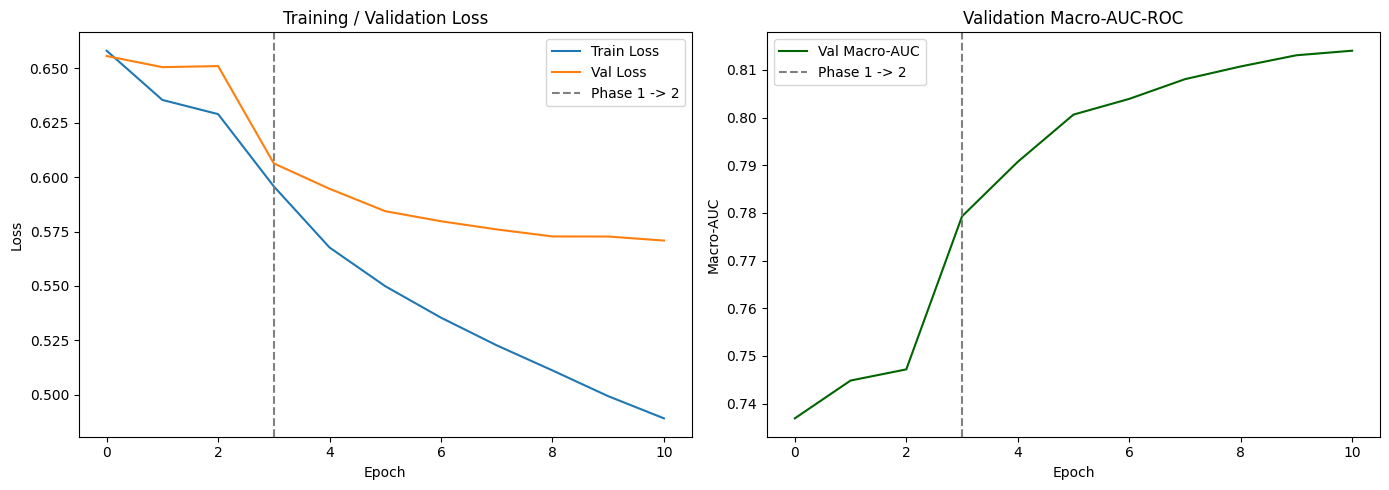

Saved: /content/drive/MyDrive/chestxray14_project/outputs/metrics/training_curves.png, /content/drive/MyDrive/chestxray14_project/outputs/metrics/training_history.csv


In [10]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch

writer = SummaryWriter(log_dir=CONFIG.logs_dir)
best_checkpoint_path = os.path.join(CONFIG.checkpoints_dir, "best_model.pth")
last_checkpoint_path = os.path.join(CONFIG.checkpoints_dir, "last_model.pth")

history = {"epoch": [], "phase": [], "train_loss": [], "val_loss": [], "val_macro_auc": [], "lr": []}

early_stopping = EarlyStopping(patience=CONFIG.early_stopping_patience, mode="max")


def run_training_phase(model, train_loader, val_loader, criterion, optimizer,
                        scheduler, scaler, device, num_epochs, disease_labels,
                        writer, phase_name, early_stopping_tracker,
                        best_ckpt_path, last_ckpt_path, history, start_epoch):
    """Run num_epochs of train/validate with checkpointing and early stopping.

    Called once per phase -- phases differ only in which parameters are
    trainable and which optimizer/scheduler are passed in. start_epoch lets
    phase 2's TensorBoard curve continue from where phase 1 left off.
    Returns the next start_epoch for the following phase.
    """
    global_epoch = start_epoch

    for local_epoch in range(num_epochs):
        epoch_start_time = time.time()

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        val_loss, val_macro_auc, _ = validate_one_epoch(
            model, val_loader, criterion, device, disease_labels
        )
        scheduler.step(val_macro_auc)
        current_lr = optimizer.param_groups[0]["lr"]
        epoch_duration = time.time() - epoch_start_time

        writer.add_scalar(f"{phase_name}/train_loss", train_loss, global_epoch)
        writer.add_scalar(f"{phase_name}/val_loss", val_loss, global_epoch)
        writer.add_scalar(f"{phase_name}/val_macro_auc", val_macro_auc, global_epoch)
        writer.add_scalar(f"{phase_name}/learning_rate", current_lr, global_epoch)

        history["epoch"].append(global_epoch)
        history["phase"].append(phase_name)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_auc"].append(val_macro_auc)
        history["lr"].append(current_lr)

        print(f"[{phase_name}] epoch {local_epoch + 1}/{num_epochs} "
              f"(global {global_epoch}) -- "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
              f"val_macro_auc={val_macro_auc:.4f} lr={current_lr:.2e} "
              f"({epoch_duration:.1f}s)")

        save_checkpoint(model, optimizer, global_epoch, val_macro_auc, last_ckpt_path)

        is_best = early_stopping_tracker.step(val_macro_auc)
        if is_best:
            save_checkpoint(model, optimizer, global_epoch, val_macro_auc, best_ckpt_path)
            print(f"  -> new best model saved (val_macro_auc={val_macro_auc:.4f})")

        global_epoch += 1

        if early_stopping_tracker.should_stop:
            print(f"  -> early stopping triggered after {local_epoch + 1} epochs in {phase_name} "
                  f"(no improvement for {early_stopping_tracker.patience} epochs)")
            break

    return global_epoch


print("Phase 1: training classifier head (backbone frozen)")

next_epoch = run_training_phase(
    model, train_loader, val_loader, criterion, optimizer, scheduler, SCALER, DEVICE,
    num_epochs=CONFIG.frozen_epochs, disease_labels=DISEASE_LABELS, writer=writer,
    phase_name="phase1_frozen", early_stopping_tracker=early_stopping,
    best_ckpt_path=best_checkpoint_path, last_ckpt_path=last_checkpoint_path,
    history=history, start_epoch=0,
)

unfreeze_all(model)
optimizer = build_optimizer(model, learning_rate=CONFIG.lr_finetune, weight_decay=CONFIG.weight_decay)
scheduler = ReduceLROnPlateau(
    optimizer, mode="max", factor=CONFIG.lr_scheduler_factor, patience=CONFIG.lr_scheduler_patience
)
num_trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nPhase 2: fine-tuning full network -- {num_trainable_now:,} params trainable, lr={CONFIG.lr_finetune}")


next_epoch = run_training_phase(
    model, train_loader, val_loader, criterion, optimizer, scheduler, SCALER, DEVICE,
    num_epochs=CONFIG.finetune_epochs, disease_labels=DISEASE_LABELS, writer=writer,
    phase_name="phase2_finetune", early_stopping_tracker=early_stopping,
    best_ckpt_path=best_checkpoint_path, last_ckpt_path=last_checkpoint_path,
    history=history, start_epoch=next_epoch,
)

writer.close()

print(f"\nTraining complete. Best val macro-AUC: {early_stopping.best_score:.4f}")
print(f"Checkpoints: {best_checkpoint_path}, {last_checkpoint_path}")

history_df = pd.DataFrame(history)
phase_boundary_epoch = history_df[history_df["phase"] == "phase2_finetune"]["epoch"].min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
if not np.isnan(phase_boundary_epoch):
    axes[0].axvline(phase_boundary_epoch, color="gray", linestyle="--", label="Phase 1 -> 2")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training / Validation Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_macro_auc"], label="Val Macro-AUC", color="darkgreen")
if not np.isnan(phase_boundary_epoch):
    axes[1].axvline(phase_boundary_epoch, color="gray", linestyle="--", label="Phase 1 -> 2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-AUC")
axes[1].set_title("Validation Macro-AUC-ROC")
axes[1].legend()

plt.tight_layout()

curves_path = os.path.join(CONFIG.metrics_dir, "training_curves.png")
plt.savefig(curves_path, dpi=150)
plt.show()

history_csv_path = os.path.join(CONFIG.metrics_dir, "training_history.csv")
history_df.to_csv(history_csv_path, index=False)
print(f"Saved: {curves_path}, {history_csv_path}")


# Cell 9: Model Evaluation
#
# Loads the best saved model and evaluates it on the test dataset.
# Calculates Accuracy, Precision, Recall, Specificity, F1-score,
# AUC-ROC, confusion matrices, and ROC curves. Results, plots,
# and evaluation metrics are saved to the metrics directory.

Evaluating checkpoint from epoch 10 (val_macro_auc=0.8140)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Per-class metrics at default threshold (0.5):
             Class  Threshold  Accuracy  Precision  Recall (Sensitivity)  Specificity  F1-Score  AUC-ROC
       Atelectasis        0.5    0.6145     0.2149                0.7653       0.5926    0.3355   0.7449
      Cardiomegaly        0.5    0.9385     0.3183                0.4178       0.9612    0.3613   0.8454
     Consolidation        0.5    0.7345     0.1325                0.4948       0.7527    0.2090   0.7050
             Edema        0.5    0.8736     0.1451                0.5103       0.8872    0.2259   0.8324
          Effusion        0.5    0.6058     0.2999                0.8778       0.5454    0.4471   0.7960
         Emphysema        0.5    0.9107     0.2570                0.5773       0.9256    0.3557   0.8630
          Fibrosis        0.5    0.9715     0.1322                0.1218       0.9862    0.1268   0.7972
            Hernia        0.5    0.9965     0.2000                0.0116       0.9998    0.0220   0.8819
      In

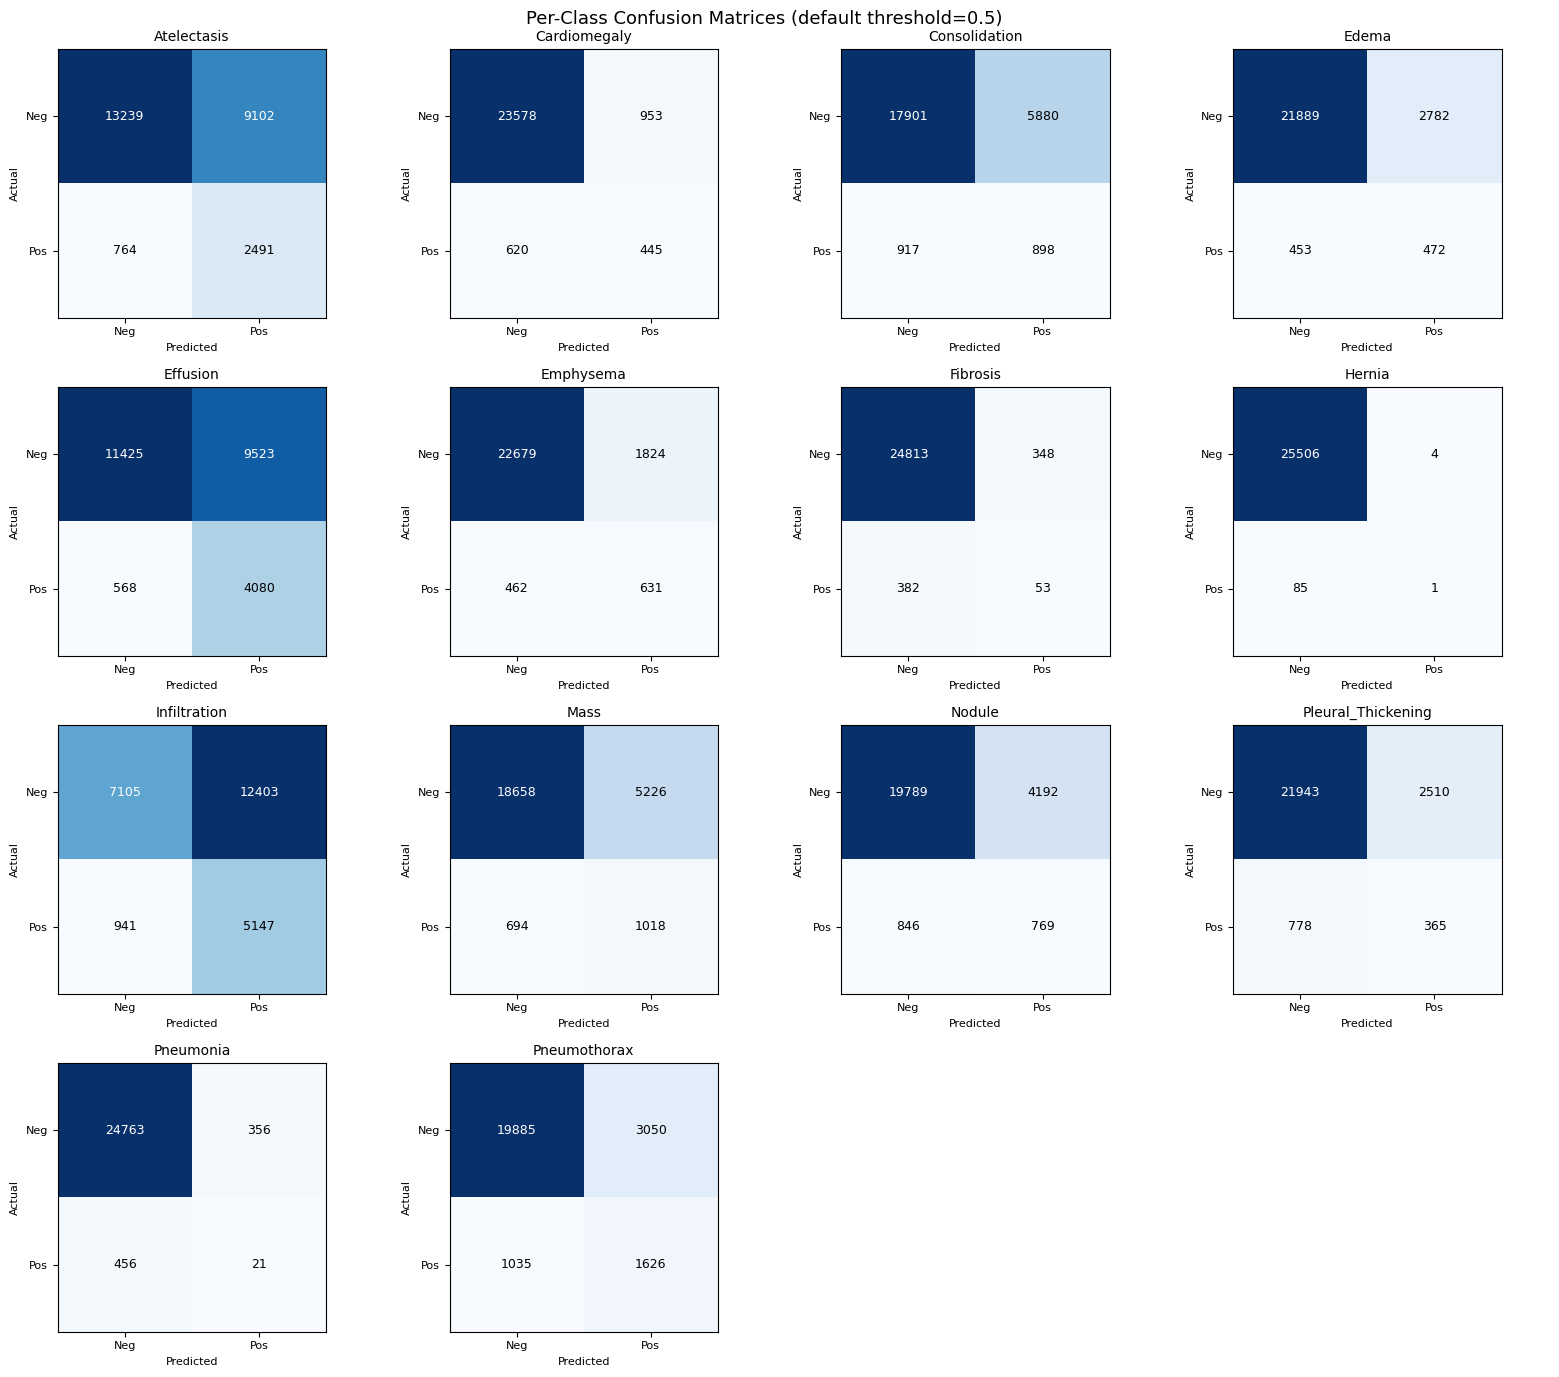

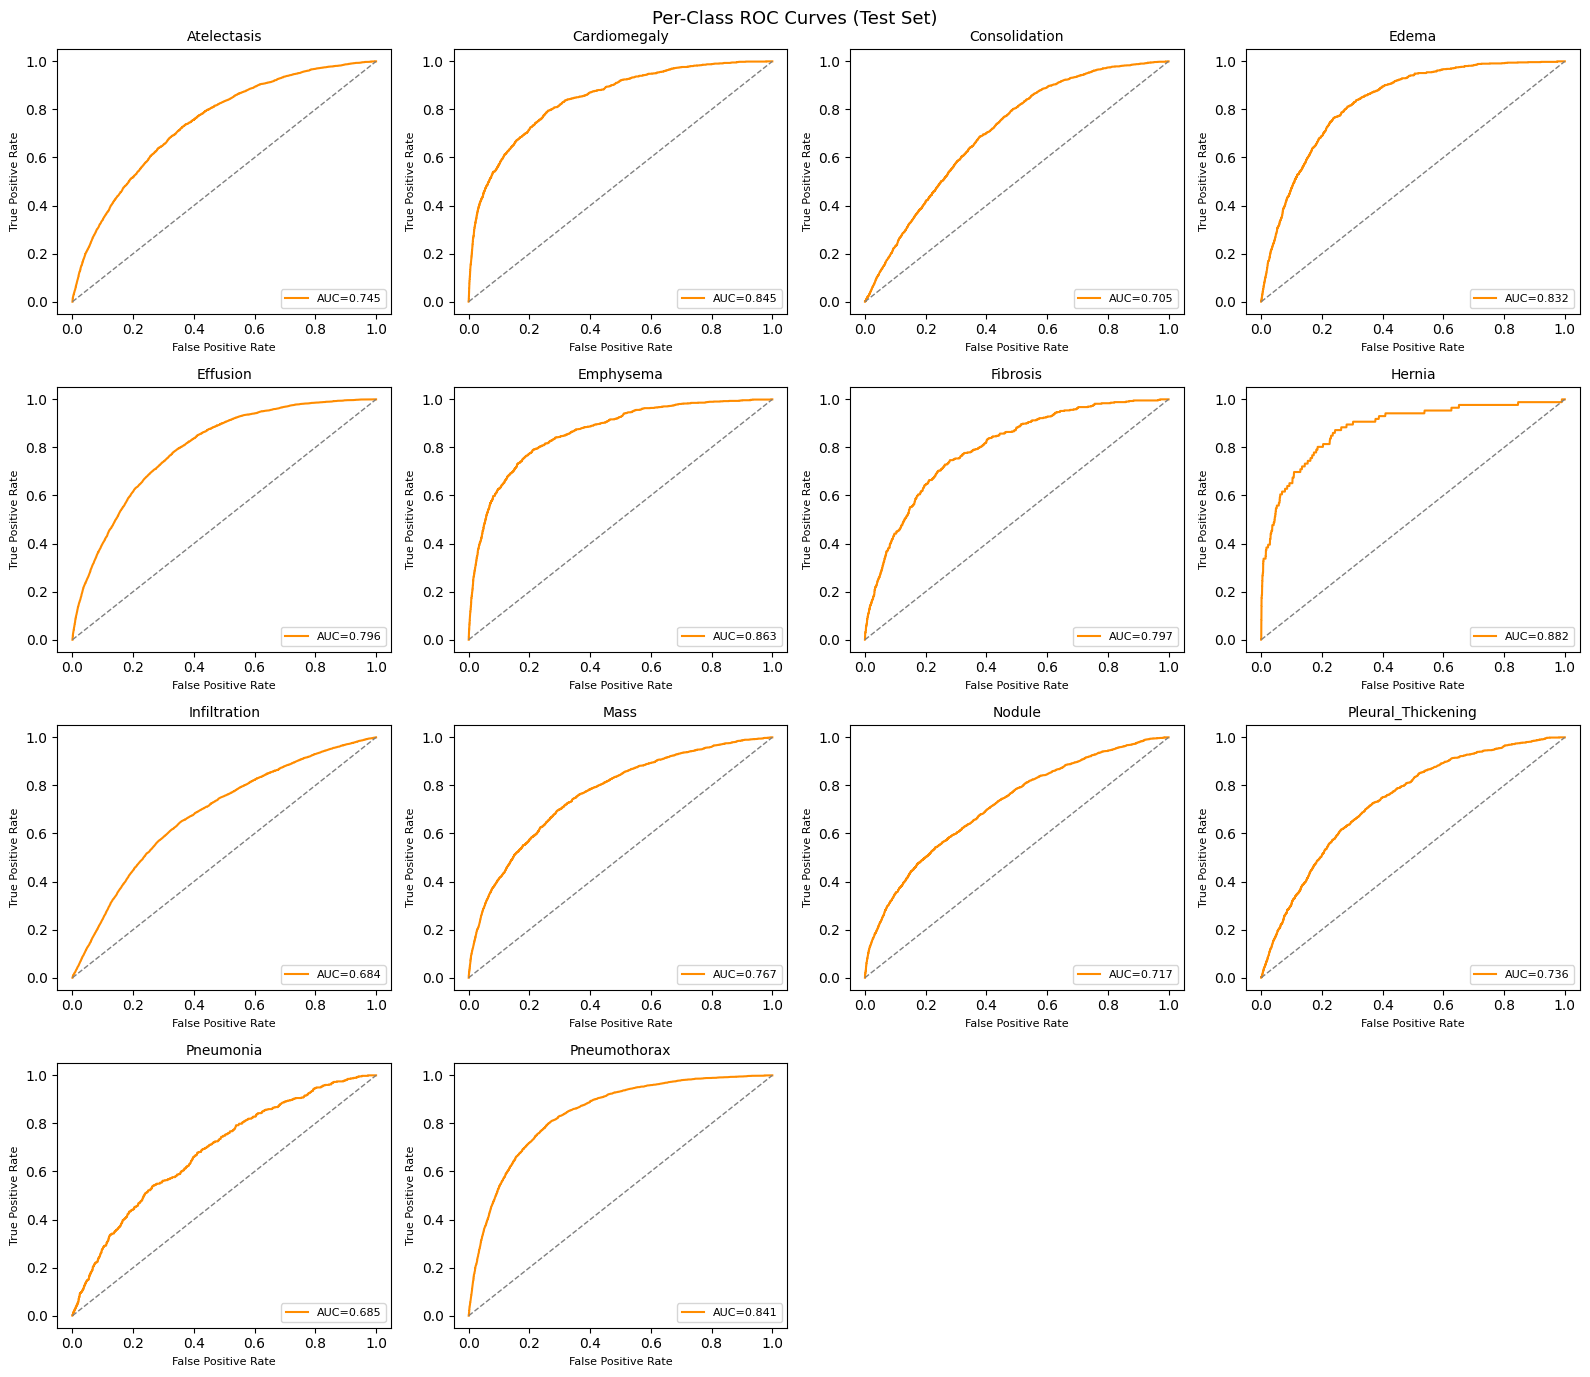


Saved: /content/drive/MyDrive/chestxray14_project/outputs/metrics/confusion_matrices.png, /content/drive/MyDrive/chestxray14_project/outputs/metrics/roc_curves.png, /content/drive/MyDrive/chestxray14_project/outputs/metrics/metrics.csv
Macro AUC-ROC: 0.7783  |  Macro F1 (default/optimal threshold): 0.2631 / 0.2341


In [11]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
)

best_checkpoint_path = os.path.join(CONFIG.checkpoints_dir, "best_model.pth")
if not os.path.exists(best_checkpoint_path):
    raise FileNotFoundError(
        f"Could not find {best_checkpoint_path}. Run Cell 8 (Training Engine) "
        "first -- this evaluates the best checkpoint it produced."
    )
checkpoint = load_checkpoint(model, best_checkpoint_path, DEVICE)
model = model.to(DEVICE)
print(f"Evaluating checkpoint from epoch {checkpoint['epoch']} (val_macro_auc={checkpoint['metric_value']:.4f})")


def get_test_predictions(model: torch.nn.Module, loader, device: torch.device) -> tuple:
    """Run inference over a DataLoader, returning (probabilities, labels) as numpy arrays."""
    model.eval()
    all_probabilities = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(images)
            probabilities = torch.sigmoid(outputs.float()).cpu().numpy()
            all_probabilities.append(probabilities)
            all_labels.append(labels.numpy())
    return np.concatenate(all_probabilities, axis=0), np.concatenate(all_labels, axis=0)


test_probabilities, test_labels = get_test_predictions(model, test_loader, DEVICE)


def find_optimal_threshold(y_true: np.ndarray, y_score: np.ndarray) -> float:
    """Find the classification threshold maximizing Youden's J (TPR - FPR).

    Falls back to 0.5 if AUC is undefined for this class (single label
    value present).
    """
    if len(np.unique(y_true)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    finite_mask = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite_mask], tpr[finite_mask], thresholds[finite_mask]
    if len(thresholds) == 0:
        return 0.5
    j_scores = tpr - fpr
    return float(thresholds[np.argmax(j_scores)])


optimal_thresholds = {
    label: find_optimal_threshold(test_labels[:, i], test_probabilities[:, i])
    for i, label in enumerate(DISEASE_LABELS)
}


def compute_classification_metrics(y_true_matrix: np.ndarray, y_prob_matrix: np.ndarray,
                                    disease_labels: list, thresholds: dict) -> pd.DataFrame:
    """Compute Accuracy, Precision, Recall, Specificity, F1, AUC-ROC per class."""
    rows = []
    for class_index, label in enumerate(disease_labels):
        y_true = y_true_matrix[:, class_index]
        y_prob = y_prob_matrix[:, class_index]
        threshold = thresholds[label]
        y_pred = (y_prob >= threshold).astype(int)

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
        auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else float("nan")

        rows.append({
            "Class": label, "Threshold": threshold, "Accuracy": accuracy,
            "Precision": precision, "Recall (Sensitivity)": recall,
            "Specificity": specificity, "F1-Score": f1, "AUC-ROC": auc,
            "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        })
    return pd.DataFrame(rows)


metrics_default_df = compute_classification_metrics(
    test_labels, test_probabilities, DISEASE_LABELS,
    thresholds={label: CONFIG.threshold_default for label in DISEASE_LABELS},
)
metrics_optimal_df = compute_classification_metrics(
    test_labels, test_probabilities, DISEASE_LABELS, thresholds=optimal_thresholds,
)

print(f"\nPer-class metrics at default threshold ({CONFIG.threshold_default}):")
print(metrics_default_df.drop(columns=["TP", "TN", "FP", "FN"]).round(4).to_string(index=False))

print("\nPer-class metrics at optimal (Youden's J) threshold:")
print(metrics_optimal_df.drop(columns=["TP", "TN", "FP", "FN"]).round(4).to_string(index=False))

macro_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "AUC-ROC"],
    "Macro Avg (default threshold)": [
        metrics_default_df["Accuracy"].mean(), metrics_default_df["Precision"].mean(),
        metrics_default_df["Recall (Sensitivity)"].mean(), metrics_default_df["Specificity"].mean(),
        metrics_default_df["F1-Score"].mean(), metrics_default_df["AUC-ROC"].mean(),
    ],
    "Macro Avg (optimal threshold)": [
        metrics_optimal_df["Accuracy"].mean(), metrics_optimal_df["Precision"].mean(),
        metrics_optimal_df["Recall (Sensitivity)"].mean(), metrics_optimal_df["Specificity"].mean(),
        metrics_optimal_df["F1-Score"].mean(), metrics_optimal_df["AUC-ROC"].mean(),
    ],
})
print("\nMacro-averaged summary:")
print(macro_summary.round(4).to_string(index=False))

num_classes = len(DISEASE_LABELS)
grid_cols = 4
grid_rows = int(np.ceil(num_classes / grid_cols))
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(4 * grid_cols, 3.5 * grid_rows))
axes_flat = np.array(axes).reshape(-1)

for i, label in enumerate(DISEASE_LABELS):
    row = metrics_default_df.iloc[i]
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])
    ax = axes_flat[i]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(label, fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Neg", "Pos"], fontsize=8)
    ax.set_yticklabels(["Neg", "Pos"], fontsize=8)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, int(cm[r, c]), ha="center", va="center",
                     color="white" if cm[r, c] > cm.max() / 2 else "black", fontsize=9)

for j in range(num_classes, len(axes_flat)):
    axes_flat[j].axis("off")

plt.suptitle("Per-Class Confusion Matrices (default threshold=0.5)", fontsize=13)
plt.tight_layout()
confusion_matrix_path = os.path.join(CONFIG.metrics_dir, "confusion_matrices.png")
plt.savefig(confusion_matrix_path, dpi=150)
plt.show()

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(4 * grid_cols, 3.5 * grid_rows))
axes_flat = np.array(axes).reshape(-1)

for i, label in enumerate(DISEASE_LABELS):
    y_true = test_labels[:, i]
    y_score = test_probabilities[:, i]
    ax = axes_flat[i]
    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, "AUC undefined\n(single class\nin test set)",
                 ha="center", va="center", fontsize=9)
        ax.set_title(label, fontsize=10)
    else:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc_value = roc_auc_score(y_true, y_score)
        ax.plot(fpr, tpr, label=f"AUC={auc_value:.3f}", color="darkorange")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
        ax.set_title(label, fontsize=10)
        ax.legend(fontsize=8, loc="lower right")
    ax.set_xlabel("False Positive Rate", fontsize=8)
    ax.set_ylabel("True Positive Rate", fontsize=8)

for j in range(num_classes, len(axes_flat)):
    axes_flat[j].axis("off")

plt.suptitle("Per-Class ROC Curves (Test Set)", fontsize=13)
plt.tight_layout()
roc_curves_path = os.path.join(CONFIG.metrics_dir, "roc_curves.png")
plt.savefig(roc_curves_path, dpi=150)
plt.show()

metrics_csv_path = os.path.join(CONFIG.metrics_dir, "metrics.csv")
combined_metrics_df = metrics_default_df.copy()
combined_metrics_df["Optimal_Threshold"] = metrics_optimal_df["Threshold"]
combined_metrics_df["Accuracy_OptimalThresh"] = metrics_optimal_df["Accuracy"]
combined_metrics_df["Precision_OptimalThresh"] = metrics_optimal_df["Precision"]
combined_metrics_df["Recall_OptimalThresh"] = metrics_optimal_df["Recall (Sensitivity)"]
combined_metrics_df["Specificity_OptimalThresh"] = metrics_optimal_df["Specificity"]
combined_metrics_df["F1_OptimalThresh"] = metrics_optimal_df["F1-Score"]
combined_metrics_df.to_csv(metrics_csv_path, index=False)

print(f"\nSaved: {confusion_matrix_path}, {roc_curves_path}, {metrics_csv_path}")
print(f"Macro AUC-ROC: {metrics_default_df['AUC-ROC'].mean():.4f}  |  "
      f"Macro F1 (default/optimal threshold): "
      f"{metrics_default_df['F1-Score'].mean():.4f} / {metrics_optimal_df['F1-Score'].mean():.4f}")


# Cell 10: Grad-CAM Explainability
#
# Generates Grad-CAM heatmaps to highlight the regions used by
# DenseNet121 for disease prediction. Heatmaps are overlaid on
# the original X-ray images, and available NIH bounding boxes
# are displayed for visual comparison. The generated results
# are saved to the Grad-CAM output directory.

Using checkpoint from epoch 10
880 image(s) have bounding-box annotations available.


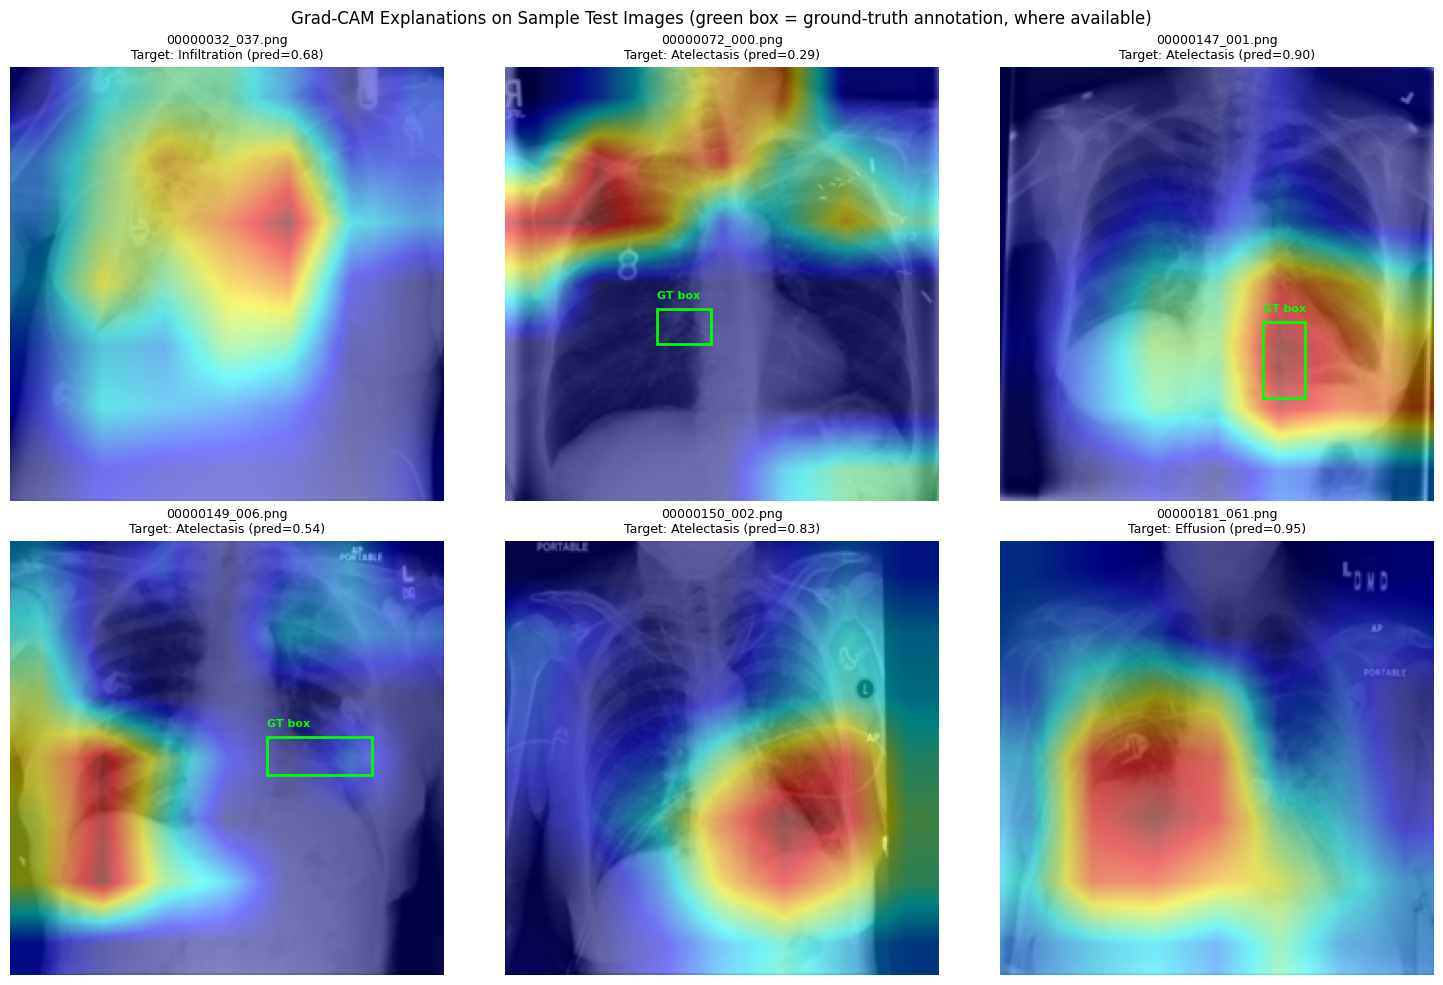

Saved 6 overlays to /content/drive/MyDrive/chestxray14_project/outputs/gradcam


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

best_checkpoint_path = os.path.join(CONFIG.checkpoints_dir, "best_model.pth")
if not os.path.exists(best_checkpoint_path):
    raise FileNotFoundError(
        f"Could not find {best_checkpoint_path}. Run Cell 8 (Training Engine) first."
    )
checkpoint = load_checkpoint(model, best_checkpoint_path, DEVICE)
model = model.to(DEVICE)
model.eval()
print(f"Using checkpoint from epoch {checkpoint['epoch']}")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
gradcam_target_layer = model.features.norm5
cam_extractor = GradCAM(model=model, target_layers=[gradcam_target_layer])


def denormalize_for_display(image_tensor: torch.Tensor) -> np.ndarray:
    """Reverse ImageNet normalization -- returns an (H, W, 3) float32 array in [0, 1]."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    denormalized = (image_tensor.cpu() * std + mean).clamp(0, 1)
    return denormalized.permute(1, 2, 0).numpy()


def generate_gradcam_overlay(image_tensor: torch.Tensor, class_index: int) -> tuple:
    """Generate a Grad-CAM heatmap overlay for one image and one target class."""

    plain_image_tensor = image_tensor.as_tensor() if hasattr(image_tensor, "as_tensor") else image_tensor
    input_batch = plain_image_tensor.unsqueeze(0).to(DEVICE)
    targets = [ClassifierOutputTarget(class_index)]

    grayscale_cam = cam_extractor(input_tensor=input_batch, targets=targets)[0]
    original_rgb = denormalize_for_display(plain_image_tensor)
    overlay = show_cam_on_image(original_rgb, grayscale_cam, use_rgb=True)
    return overlay, grayscale_cam


def load_bbox_data(bbox_csv_path: str, image_size: int, original_image_size: int = 1024) -> dict:
    """Load ground-truth bounding boxes, keyed by image filename.

    Columns are read by position since the official CSV's header is
    malformed. Returns an empty dict (rather than raising) if the file
    doesn't match the expected structure.
    """
    try:
        bbox_raw = pd.read_csv(bbox_csv_path)
    except Exception as read_error:
        print(f"WARNING: could not read {bbox_csv_path} ({read_error}) -- "
              f"proceeding without bounding-box overlays.")
        return {}

    if bbox_raw.shape[1] < 6 or len(bbox_raw) == 0:
        print(f"WARNING: {bbox_csv_path} did not have the expected column "
              f"structure (>=6 columns: Image Index, Finding Label, x, y, w, h) "
              f"-- proceeding without bounding-box overlays.")
        return {}

    scale_factor = image_size / original_image_size
    bbox_map = {}
    for _, row in bbox_raw.iterrows():
        try:
            image_name = str(row.iloc[0])
            finding_label = str(row.iloc[1])
            x, y, w, h = (float(row.iloc[2]) * scale_factor, float(row.iloc[3]) * scale_factor,
                          float(row.iloc[4]) * scale_factor, float(row.iloc[5]) * scale_factor)
        except (ValueError, TypeError):
            continue
        bbox_map.setdefault(image_name, []).append((finding_label, x, y, w, h))
    return bbox_map


bbox_data = load_bbox_data(CONFIG.bbox_csv, CONFIG.image_size)
print(f"{len(bbox_data)} image(s) have bounding-box annotations available.")

test_manifest_df = pd.read_csv(os.path.join(CONFIG.splits_dir, "test.csv"))


has_positive_finding = test_manifest_df[DISEASE_LABELS].sum(axis=1) > 0
bbox_available = test_manifest_df["Image Index"].isin(bbox_data.keys())

num_samples = min(6, len(test_manifest_df))
priority_df = test_manifest_df[has_positive_finding & bbox_available]
fallback_df = test_manifest_df[has_positive_finding & ~bbox_available]

sample_df = pd.concat([priority_df, fallback_df]).head(num_samples)
if len(sample_df) < num_samples:
    remaining = num_samples - len(sample_df)
    extra_df = test_manifest_df[~test_manifest_df["Image Index"].isin(sample_df["Image Index"])].head(remaining)
    sample_df = pd.concat([sample_df, extra_df])

grid_cols = 3
grid_rows = int(np.ceil(len(sample_df) / grid_cols))
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(5 * grid_cols, 5 * grid_rows))
axes_flat = np.array(axes).reshape(-1) if len(sample_df) > 1 else [axes]

for plot_index, (_, row) in enumerate(sample_df.iterrows()):
    image_filename = row["Image Index"]
    image_path = os.path.join(CONFIG.images_dir, image_filename)
    pil_image = Image.open(image_path).convert("L")
    image_array = np.array(pil_image)
    image_tensor = eval_transforms(image_array)


    positive_indices = [i for i, label in enumerate(DISEASE_LABELS) if row[label] == 1]
    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    if positive_indices:
        target_class_index = max(positive_indices, key=lambda i: probs[i])
    else:
        target_class_index = int(np.argmax(probs))
    target_class_name = DISEASE_LABELS[target_class_index]

    overlay, grayscale_cam = generate_gradcam_overlay(image_tensor, target_class_index)

    ax = axes_flat[plot_index]
    ax.imshow(overlay)
    ax.set_title(f"{image_filename}\nTarget: {target_class_name} "
                 f"(pred={probs[target_class_index]:.2f})", fontsize=9)
    ax.axis("off")

    if image_filename in bbox_data:
        for finding_label, x, y, w, h in bbox_data[image_filename]:
            if finding_label.strip().lower() == target_class_name.strip().lower():
                rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                          edgecolor="lime", facecolor="none")
                ax.add_patch(rect)
                ax.text(x, max(y - 5, 0), "GT box", color="lime", fontsize=8, weight="bold")

    overlay_save_path = os.path.join(
        CONFIG.gradcam_dir, f"{os.path.splitext(image_filename)[0]}_{target_class_name}.png"
    )
    Image.fromarray(overlay).save(overlay_save_path)

for j in range(len(sample_df), len(axes_flat)):
    axes_flat[j].axis("off")

plt.suptitle("Grad-CAM Explanations on Sample Test Images "
             "(green box = ground-truth annotation, where available)", fontsize=12)
plt.tight_layout()
gradcam_grid_path = os.path.join(CONFIG.gradcam_dir, "gradcam_grid_summary.png")
plt.savefig(gradcam_grid_path, dpi=150)
plt.show()

print(f"Saved {len(sample_df)} overlays to {CONFIG.gradcam_dir}")


# Cell 11: Inference Demo
#
# Defines a prediction function that takes a chest X-ray image,
# performs disease classification, and generates Grad-CAM
# visualizations for the predicted classes. The function is
# tested on sample images and can be used for real-time inference.


Ground truth: ['Atelectasis', 'Mass']

Predictions for 00013659_006.png:
  Mass           : 0.853 <-- detected
  Effusion       : 0.786 <-- detected
  Pneumothorax   : 0.687 <-- detected
  Pleural_Thickening: 0.594 <-- detected
  Atelectasis    : 0.487
  Nodule         : 0.486
  Emphysema      : 0.446
  Infiltration   : 0.363
  Consolidation  : 0.320
  Fibrosis       : 0.258
  Hernia         : 0.160
  Pneumonia      : 0.030
  Cardiomegaly   : 0.022
  Edema          : 0.018


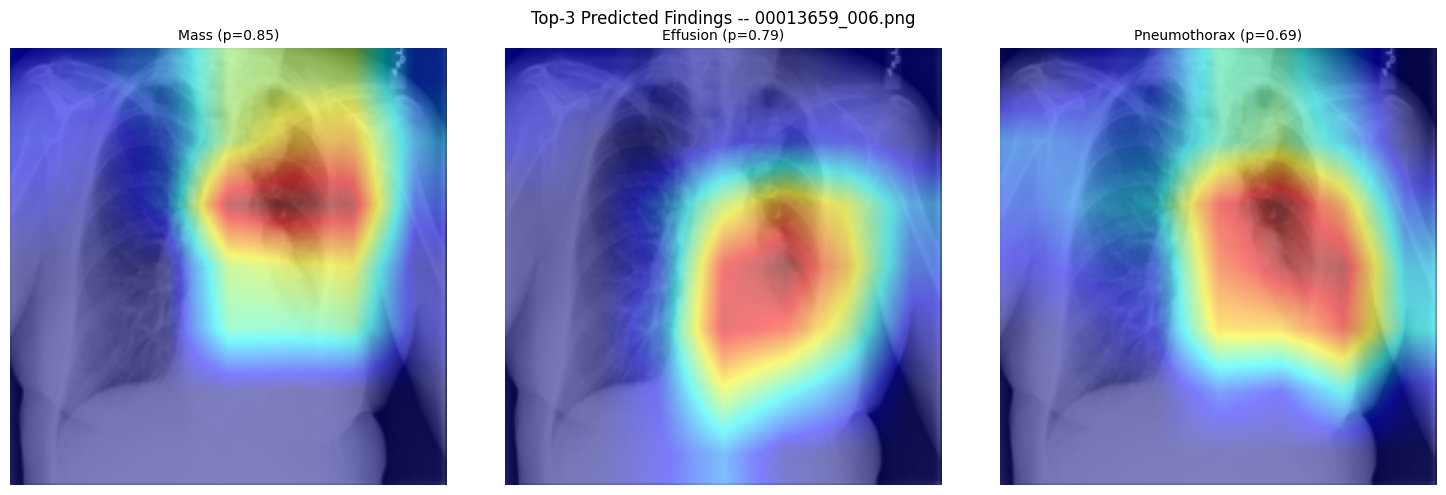


Ground truth: ['No Finding']

Predictions for 00030445_000.png:
  Infiltration   : 0.472
  Mass           : 0.365
  Nodule         : 0.302
  Pleural_Thickening: 0.184
  Atelectasis    : 0.152
  Consolidation  : 0.144
  Fibrosis       : 0.089
  Pneumonia      : 0.079
  Effusion       : 0.061
  Pneumothorax   : 0.033
  Emphysema      : 0.015
  Edema          : 0.011
  Cardiomegaly   : 0.002
  Hernia         : 0.002
  (no class exceeded the 0.5 detection threshold)


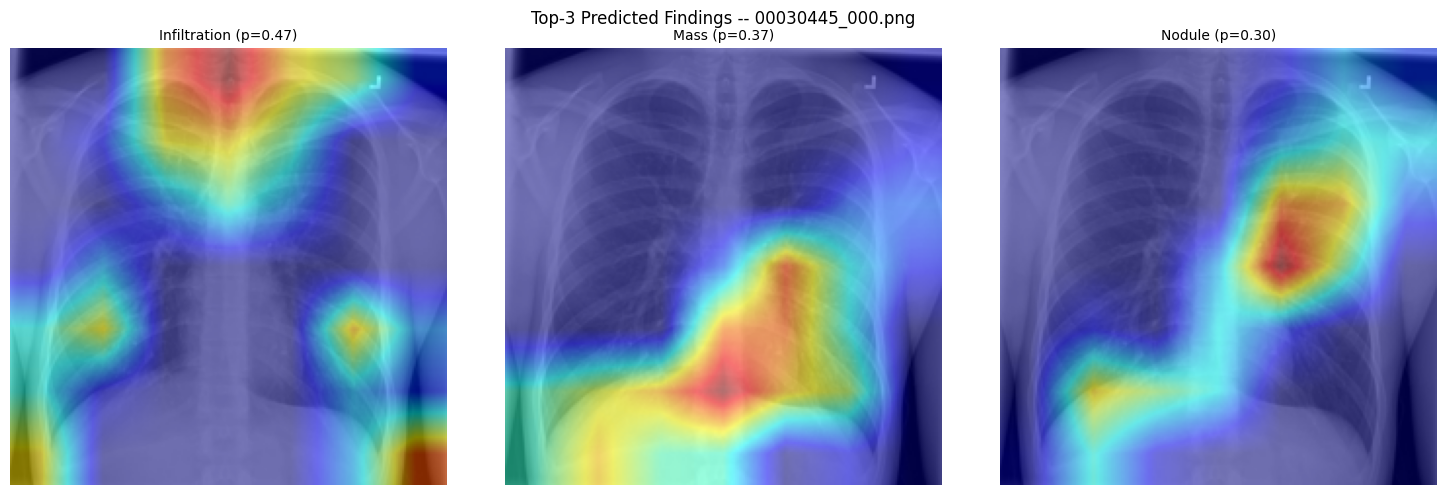

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

best_checkpoint_path = os.path.join(CONFIG.checkpoints_dir, "best_model.pth")
if not os.path.exists(best_checkpoint_path):
    raise FileNotFoundError(
        f"Could not find {best_checkpoint_path}. Run Cell 8 (Training Engine) first."
    )
checkpoint = load_checkpoint(model, best_checkpoint_path, DEVICE)
model = model.to(DEVICE)
model.eval()


def predict_and_explain(image_path: str, threshold: float = 0.5, top_k_gradcam: int = 3,
                         show_plot: bool = True) -> dict:
    """Predict findings for a chest X-ray and generate Grad-CAM for the top predictions.

    Returns a dict with "image_path", "probabilities" (per class),
    "detected_findings" (>= threshold), and "top_k_classes".
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    pil_image = Image.open(image_path).convert("L")
    image_array = np.array(pil_image)
    image_tensor = eval_transforms(image_array)

    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(DEVICE))
        probabilities = torch.sigmoid(logits).cpu().numpy()[0]

    probability_dict = {label: float(prob) for label, prob in zip(DISEASE_LABELS, probabilities)}
    detected_findings = [label for label, prob in probability_dict.items() if prob >= threshold]
    ranked_classes = sorted(probability_dict, key=probability_dict.get, reverse=True)
    top_k_classes = ranked_classes[:top_k_gradcam]

    print(f"\nPredictions for {os.path.basename(image_path)}:")
    for label in ranked_classes:
        marker = " <-- detected" if probability_dict[label] >= threshold else ""
        print(f"  {label:15s}: {probability_dict[label]:.3f}{marker}")
    if not detected_findings:
        print(f"  (no class exceeded the {threshold} detection threshold)")

    if show_plot:
        fig, axes = plt.subplots(1, top_k_gradcam, figsize=(5 * top_k_gradcam, 5))
        if top_k_gradcam == 1:
            axes = [axes]
        for ax, class_name in zip(axes, top_k_classes):
            class_index = DISEASE_LABELS.index(class_name)
            overlay, _ = generate_gradcam_overlay(image_tensor, class_index)
            ax.imshow(overlay)
            ax.set_title(f"{class_name} (p={probability_dict[class_name]:.2f})", fontsize=10)
            ax.axis("off")
        plt.suptitle(f"Top-{top_k_gradcam} Predicted Findings -- {os.path.basename(image_path)}", fontsize=12)
        plt.tight_layout()
        plt.show()

    return {
        "image_path": image_path,
        "probabilities": probability_dict,
        "detected_findings": detected_findings,
        "top_k_classes": top_k_classes,
    }


test_manifest_df = pd.read_csv(os.path.join(CONFIG.splits_dir, "test.csv"))
demo_sample = test_manifest_df.sample(n=min(2, len(test_manifest_df)), random_state=CONFIG.random_seed)

for _, row in demo_sample.iterrows():
    demo_image_path = os.path.join(CONFIG.images_dir, row["Image Index"])
    ground_truth = [label for label in DISEASE_LABELS if row[label] == 1] or ["No Finding"]
    print(f"\nGround truth: {ground_truth}")
    result = predict_and_explain(demo_image_path, threshold=CONFIG.threshold_default, top_k_gradcam=3)


# Cell 12: Project Summary
#
# This project implements a multi-label chest X-ray disease classification
# system using the NIH ChestX-ray14 dataset and a DenseNet121 model with
# transfer learning. The workflow includes dataset preparation, multi-label
# encoding, patient-disjoint data splitting, MONAI-based preprocessing,
# two-phase training, and model evaluation using standard medical metrics.
#
# Grad-CAM is used to visualize the regions that influence the model's
# predictions, improving the interpretability of the results. The trained
# model, evaluation metrics, plots, and Grad-CAM outputs are saved for
# further analysis and can be used as a baseline for future improvements.